<a href="https://colab.research.google.com/github/Aflian/COLLAB-ANDRA/blob/main/FIX_CHATBOT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q sentence-transformers scikit-learn pandas numpy torch matplotlib deep-translator


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.5 MB/s eta 0:00:00


In [2]:
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, r2_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

df = pd.read_csv("/content/drive/MyDrive/skripsi/terjemah.csv")
df = df.dropna(subset=["Context_clean", "Response_clean"]).reset_index(drop=True)

# --- Terjemahkan kolom Response ke Bahasa Indonesia (jalankan SEKALI) ---
# Set False jika kolom Response sudah berbahasa Indonesia.
TRANSLATE = True

if TRANSLATE:
    from deep_translator import GoogleTranslator
    from tqdm import tqdm

    def translate_id(texts):
        out, translator = [], GoogleTranslator(source="auto", target="id")
        for t in tqdm(texts):
            try:
                out.append(translator.translate(str(t)[:4900]))
            except Exception:
                out.append(str(t))
        return out

    df["Response_id"] = translate_id(df["Response"].tolist())
    df.to_csv("dataset_id.csv", index=False)   # simpan agar tidak menerjemah ulang
else:
    df["Response_id"] = df["Response"]

print("Jumlah pasangan:", len(df))
df[["Response", "Response_id"]].head()


Device: cpu


100%|██████████| 3507/3507 [46:00<00:00,  1.27it/s]


Jumlah pasangan: 3507


,Response,Response_id
0,"If everyone thinks you're worthless, then mayb...","Jika semua orang berpikir Anda tidak berharga,..."
1,"Hello, and thank you for your question and see...","Halo, dan terima kasih atas pertanyaan Anda da..."
2,First thing I'd suggest is getting the sleep y...,Hal pertama yang saya sarankan adalah mendapat...
3,Therapy is essential for those that are feelin...,Terapi sangat penting bagi mereka yang merasa ...
4,I first want to let you know that you are not ...,Pertama-tama saya ingin memberi tahu Anda bahw...


In [3]:
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2",
                               device=str(device))

contexts  = df["Context_clean"].astype(str).tolist()
responses = df["Response_clean"].astype(str).tolist()        # untuk embedding/komputasi
responses_display = df["Response_id"].astype(str).tolist()   # untuk DITAMPILKAN (Bhs Indonesia)

ctx_emb  = embedder.encode(contexts, convert_to_numpy=True,
                           show_progress_bar=True, normalize_embeddings=True)
resp_emb = embedder.encode(responses, convert_to_numpy=True,
                           show_progress_bar=True, normalize_embeddings=True)
EMB_DIM = ctx_emb.shape[1]
print("Dimensi embedding:", EMB_DIM)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/110 [00:00<?, ?it/s]

Batches:   0%|          | 0/110 [00:00<?, ?it/s]

Dimensi embedding: 384


In [4]:
def build_pairs(ctx_emb, resp_emb, n_neg=1, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(ctx_emb)
    X_ctx, X_resp, y = [], [], []
    for i in range(n):
        X_ctx.append(ctx_emb[i]); X_resp.append(resp_emb[i]); y.append(1.0)
        for _ in range(n_neg):
            j = rng.integers(0, n)
            while j == i:
                j = rng.integers(0, n)
            X_ctx.append(ctx_emb[i]); X_resp.append(resp_emb[j]); y.append(0.0)
    return (np.array(X_ctx, dtype=np.float32),
            np.array(X_resp, dtype=np.float32),
            np.array(y, dtype=np.float32))

def make_features(Xc, Xr):
    # [ctx, resp, |ctx-resp|, ctx*resp] -> kaya informasi interaksi
    return np.concatenate([Xc, Xr, np.abs(Xc - Xr), Xc * Xr], axis=1)

Xc, Xr, y = build_pairs(ctx_emb, resp_emb, n_neg=1)
X = make_features(Xc, Xr)
print("Total sampel:", len(y), "| Positif:", int(y.sum()),
      "| Negatif:", int((y == 0).sum()))
print("Dimensi fitur input:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)


Total sampel: 7014 | Positif: 3507 | Negatif: 3507
Dimensi fitur input: (7014, 1536)


In [5]:
class TriangularFuzzyLayer(nn.Module):
    """
    Fuzzifikasi tiap fitur menjadi derajat keanggotaan terhadap K himpunan
    fuzzy bermembership segitiga. Center & width dilatih adaptif (neuro-fuzzy).
    """
    def __init__(self, in_dim, n_fuzzy=3):
        super().__init__()
        self.in_dim = in_dim
        self.n_fuzzy = n_fuzzy
        centers = torch.linspace(-1.0, 1.0, n_fuzzy).repeat(in_dim, 1)
        self.centers = nn.Parameter(centers)                   # (in_dim, n_fuzzy)
        self.widths  = nn.Parameter(torch.ones(in_dim, n_fuzzy) * 0.5)

    def forward(self, x):
        x = x.unsqueeze(-1)                                    # (batch, in_dim, 1)
        c = self.centers.unsqueeze(0)                          # (1, in_dim, n_fuzzy)
        w = torch.clamp(self.widths.unsqueeze(0), min=1e-4)
        # Membership segitiga: max(0, 1 - |x - c| / w)
        membership = torch.clamp(1.0 - torch.abs(x - c) / w, min=0.0)
        return membership.reshape(x.size(0), -1)               # (batch, in_dim*n_fuzzy)


In [6]:
class TFNN(nn.Module):
    def __init__(self, in_dim, n_fuzzy=3, hidden=128, dropout=0.3):
        super().__init__()
        self.fuzzy = TriangularFuzzyLayer(in_dim, n_fuzzy)
        fuzzy_out = in_dim * n_fuzzy
        self.net = nn.Sequential(
            nn.Linear(fuzzy_out, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x):
        f = self.fuzzy(x)
        score = self.net(f)                       # logit
        return torch.sigmoid(score).squeeze(-1)   # defuzzifikasi -> skor [0,1]

model = TFNN(in_dim=X.shape[1], n_fuzzy=3).to(device)
fuzzy_awal = copy.deepcopy(model.fuzzy)   # simpan kondisi awal untuk visualisasi
print(model)


TFNN(
  (fuzzy): TriangularFuzzyLayer()
  (net): Sequential(
    (0): Linear(in_features=4608, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [7]:
class PairDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(PairDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader  = DataLoader(PairDataset(X_test,  y_test),  batch_size=128)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

def eval_loss(loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            total += criterion(model(xb), yb).item() * xb.size(0)
    return total / len(loader.dataset)

EPOCHS = 30
history = {"train_loss": [], "val_loss": []}
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    train_loss = total_loss / len(train_loader.dataset)
    val_loss = eval_loss(test_loader)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")


Epoch 01 | Train: 0.7026 | Val: 0.6938
Epoch 05 | Train: 0.6931 | Val: 0.6931
Epoch 10 | Train: 0.6932 | Val: 0.6931
Epoch 15 | Train: 0.6932 | Val: 0.6929
Epoch 20 | Train: 0.5333 | Val: 0.4846
Epoch 25 | Train: 0.4594 | Val: 0.4610
Epoch 30 | Train: 0.4234 | Val: 0.4321


In [8]:
model.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        all_pred.append(model(xb).cpu().numpy())
        all_true.append(yb.numpy())

y_score = np.concatenate(all_pred)            # skor relevansi kontinu [0,1]
y_true  = np.concatenate(all_true)
y_pred  = (y_score >= 0.5).astype(int)

print("=== Hasil Evaluasi TFNN ===")
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_true, y_pred):.4f}")
print(f"R2 Score : {r2_score(y_true, y_score):.4f}")


=== Hasil Evaluasi TFNN ===
Accuracy : 0.8097
Precision: 0.7940
Recall   : 0.8359
F1-Score : 0.8145
R2 Score : 0.4515


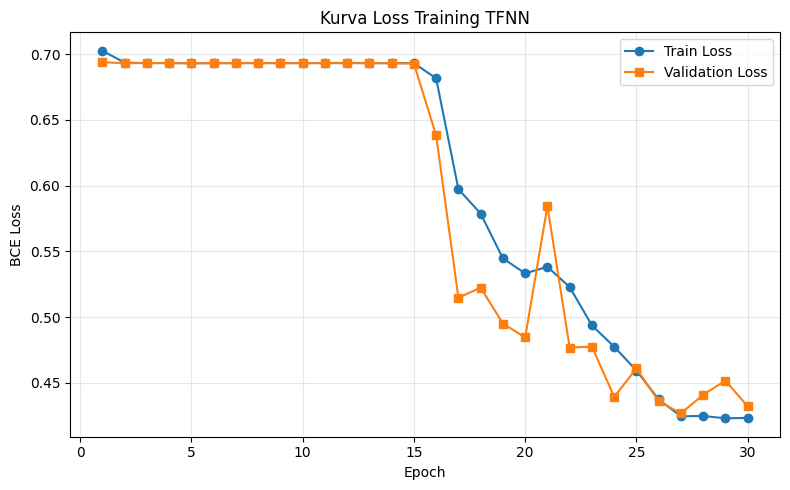

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history["train_loss"])+1), history["train_loss"],
         marker="o", label="Train Loss")
plt.plot(range(1, len(history["val_loss"])+1), history["val_loss"],
         marker="s", label="Validation Loss")
plt.title("Kurva Loss Training TFNN")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("kurva_loss.png", dpi=150); plt.show()


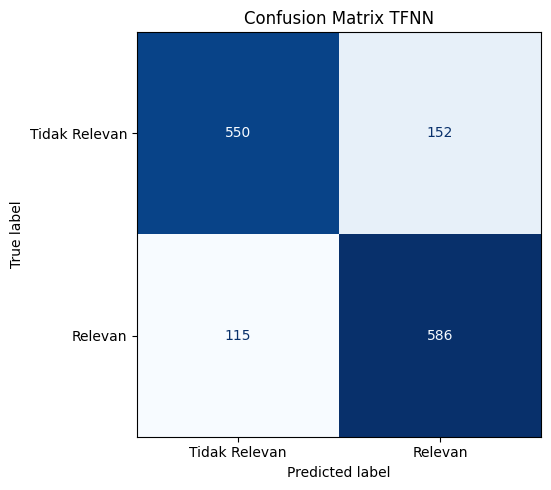

In [10]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Tidak Relevan", "Relevan"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Confusion Matrix TFNN")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150); plt.show()


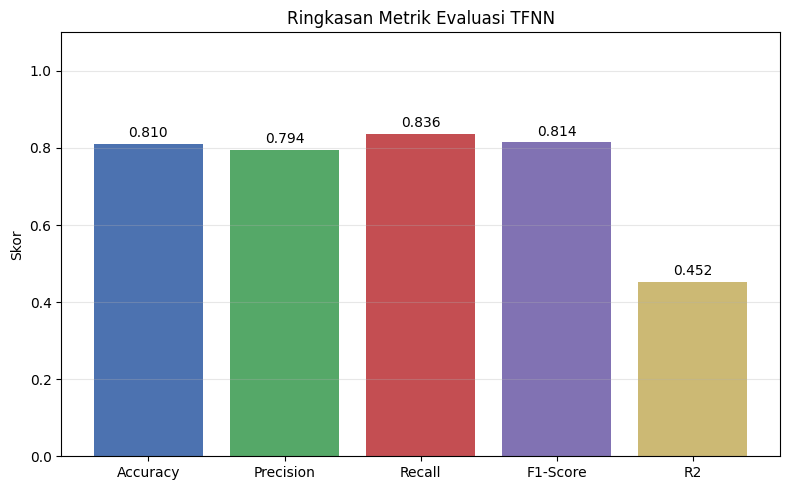

In [11]:
metrics = {
    "Accuracy":  accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred),
    "Recall":    recall_score(y_true, y_pred),
    "F1-Score":  f1_score(y_true, y_pred),
    "R2":        r2_score(y_true, y_score),
}
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics.keys(), metrics.values(),
               color=["#4C72B0","#55A868","#C44E52","#8172B3","#CCB974"])
for bar, val in zip(bars, metrics.values()):
    plt.text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.3f}",
             ha="center", va="bottom", fontsize=10)
plt.ylim(0, 1.1); plt.title("Ringkasan Metrik Evaluasi TFNN")
plt.ylabel("Skor"); plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("ringkasan_metrik.png", dpi=150); plt.show()


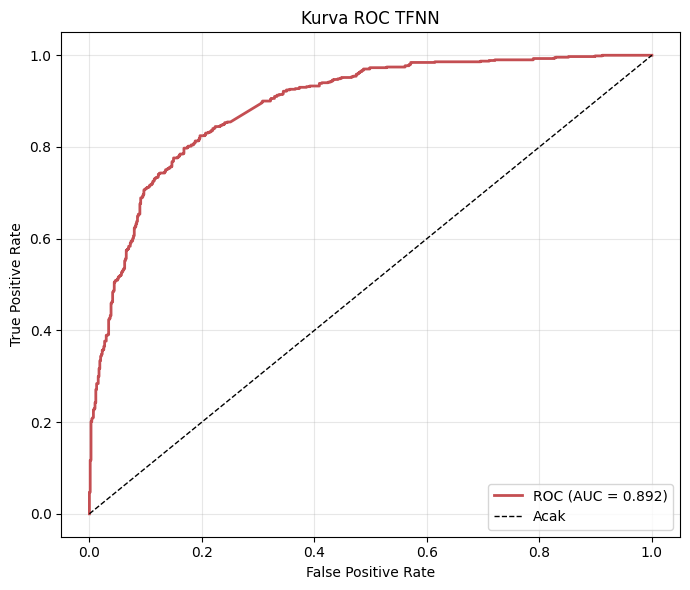

In [12]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#C44E52", lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Acak")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Kurva ROC TFNN")
plt.legend(loc="lower right"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("roc_curve.png", dpi=150); plt.show()


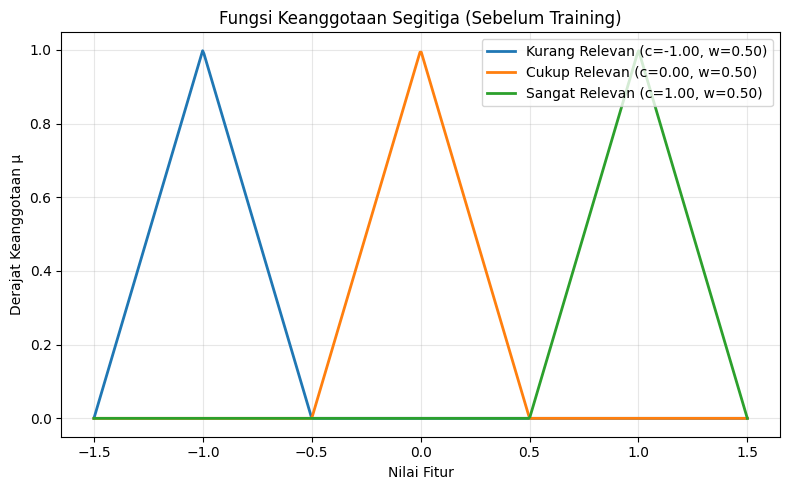

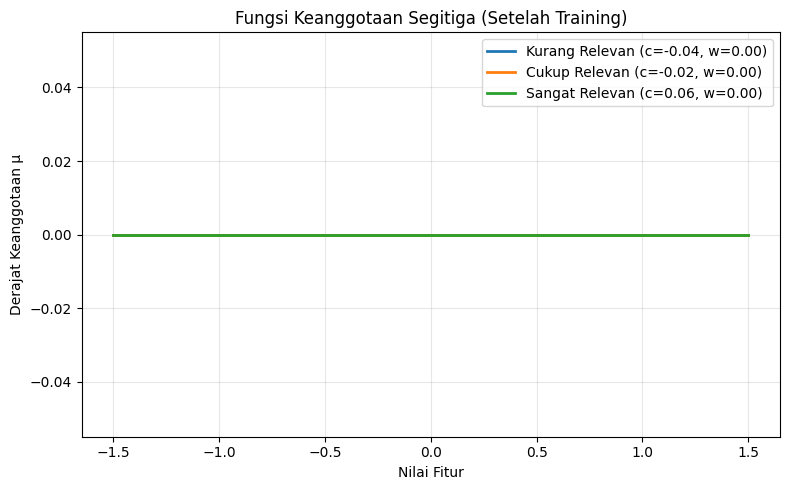

In [13]:
def plot_membership(layer, feature_idx=0, title=""):
    centers = layer.centers.detach().cpu().numpy()[feature_idx]
    widths  = torch.clamp(layer.widths, min=1e-4).detach().cpu().numpy()[feature_idx]
    x = np.linspace(-1.5, 1.5, 500)
    plt.figure(figsize=(8, 5))
    labels = ["Kurang Relevan", "Cukup Relevan", "Sangat Relevan"]
    for k in range(len(centers)):
        mu = np.clip(1.0 - np.abs(x - centers[k]) / widths[k], 0, None)
        lbl = labels[k] if k < len(labels) else f"Fuzzy {k+1}"
        plt.plot(x, mu, lw=2, label=f"{lbl} (c={centers[k]:.2f}, w={widths[k]:.2f})")
    plt.title(title); plt.xlabel("Nilai Fitur"); plt.ylabel("Derajat Keanggotaan μ")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

plot_membership(fuzzy_awal, 0, "Fungsi Keanggotaan Segitiga (Sebelum Training)")
plot_membership(model.fuzzy, 0, "Fungsi Keanggotaan Segitiga (Setelah Training)")


In [14]:
def jawab_chatbot(pertanyaan, top_k=3):
    q_emb = embedder.encode([pertanyaan], convert_to_numpy=True,
                            normalize_embeddings=True)
    q_rep = np.repeat(q_emb, len(resp_emb), axis=0)
    feats = make_features(q_rep, resp_emb)
    model.eval()
    with torch.no_grad():
        scores = model(torch.tensor(feats, dtype=torch.float32).to(device)).cpu().numpy()
    idx = scores.argsort()[::-1][:top_k]
    print("Pertanyaan:", pertanyaan, "\n")
    for rank, i in enumerate(idx, 1):
        print(f"[{rank}] skor relevansi = {scores[i]:.3f}")
        print("Jawaban:", responses_display[i], "\n")   # kalimat utuh, Bahasa Indonesia

jawab_chatbot("saya merasa cemas dan tidak bisa tidur")


Pertanyaan: saya merasa cemas dan tidak bisa tidur 

[1] skor relevansi = 0.988
Jawaban: Sepertinya Anda menyadari diri Anda diliputi kecemasan, merasa lebih mudah tersinggung, dan kesulitan untuk tidur secara konsisten. Ada banyak kemungkinan, sehubungan dengan apa yang mungkin berkontribusi terhadap hal-hal yang Anda perhatikan ini, dan terapis yang kompeten mungkin dapat membantu. Dalam terapi, Anda mungkin bisa mendapatkan wawasan tentang pengalaman-pengalaman ini serta mengembangkan strategi untuk mengatasi dan pada akhirnya mengurangi kecemasan, mudah tersinggung, dan tidur yang tidak konsisten. 

[2] skor relevansi = 0.988
Jawaban: Sepertinya Anda menyadari diri Anda diliputi kecemasan, merasa lebih mudah tersinggung, dan kesulitan untuk tidur secara konsisten. Ada banyak kemungkinan, sehubungan dengan apa yang mungkin berkontribusi terhadap hal-hal yang Anda perhatikan ini, dan terapis yang kompeten mungkin dapat membantu. Dalam terapi, Anda mungkin bisa mendapatkan wawasan ten